Project Title: Predicting Song Popularity Using Regression Models on Spotify Global Music Dataset

Dataset Link: Spotify Global Music Dataset (2009–2025)
https://www.kaggle.com/datasets/wardabilal/spotify-global-music-dataset-20092025?utm_source=chatgpt.com
This dataset contains a large collection of global Spotify songs with various features and metadata spanning from 2009 to 2025.

Problem Statement: The objective of this project is to predict the popularity score of a song using its audio features such as danceability, energy, loudness, tempo, and duration by applying regression techniques.

Objective: To build and evaluate regression models that predict Spotify song popularity using audio features from a large global dataset.

Target & Features
1. Target Variable:
-> popularity (0–100)
2. Independent Variables
-> danceability
-> energy
-> loudness
-> tempo
-> valence
-> duration_ms
This makes it a Multiple Linear Regression problem.

Regression Models Used
| Model                      | Purpose                  |
| -------------------------- | ------------------------ |
| Linear Regression          | Baseline model           |
| Multiple Linear Regression | Uses multiple features   |
| Ridge Regression           | Reduces overfitting (L2) |
| Lasso Regression           | Feature selection (L1)   |


Tools & Libraries
1. Python
2. Pandas
3. NumPy
4. Scikit-learn
5. Matplotlib

Project Workflow
1. Load dataset
2. Clean missing values
3. Select features & target
4. Train-test split
5. Train regression models
6. Compare performance

STEP 1: Import Required Libraries

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt


STEP 2: Load Dataset

In [7]:
# Load the dataset
data = pd.read_csv("spotify_data clean.csv")

# Display dataset info
print(data.head())
print("\nColumns:\n", data.columns)


                 track_id                                       track_name  \
0  3EJS5LyekDim1Tf5rBFmZl                    Trippy Mane (ft. Project Pat)   
1  1oQW6G2ZiwMuHqlPpP27DB                                             OMG!   
2  7mdkjzoIYlf1rx9EtBpGmU                                      Hard 2 Find   
3  67rW0Zl7oB3qEpD5YWWE5w  Still Get Like That (ft. Project Pat & Starrah)   
4  15xptTfRBrjsppW0INUZjf                            ride me like a harley   

   track_number  track_popularity  explicit artist_name  artist_popularity  \
0             4                 0      True       Diplo                 77   
1             1                 0      True    Yelawolf                 64   
2             1                 4      True   Riff Raff                 48   
3             8                30      True       Diplo                 77   
4             2                 0      True     Rumelis                 48   

   artist_followers                      artist_genres  \
0   

STEP 3: Select Features & Target

Target Variable

In [8]:
y = data['track_popularity']


Feature Variables

In [9]:
features = [
    'artist_popularity',
    'artist_followers',
    'track_number',
    'album_total_tracks',
    'track_duration_min'
]

X = data[features]


STEP 4: Handle Missing Values

In [10]:
X = X.fillna(X.mean())
y = y.fillna(y.mean())


STEP 5: Train–Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

STEP 6: Linear Regression

In [13]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("🔹 Linear Regression")
print("R2 Score:", r2_score(y_test, linear_pred))
rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
print("RMSE:", rmse)
print("-" * 40)

🔹 Linear Regression
R2 Score: 0.27328933129434585
RMSE: 20.78275214003277
----------------------------------------


STEP 7: Multiple Linear Regression

In [21]:
# R2 Score
r2 = r2_score(y_test, multiple_pred)

# RMSE (manual)
rmse = np.sqrt(mean_squared_error(y_test, multiple_pred))

print("🔹 Multiple Linear Regression")
print("R2 Score:", r2)
print("RMSE:", rmse)
print("-" * 40)


🔹 Multiple Linear Regression
R2 Score: 0.27328933129434585
RMSE: 20.78275214003277
----------------------------------------


STEP 8: Ridge Regression (L2 Regularization)

In [16]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

print("🔹 Ridge Regression")
print("R2 Score:", r2_score(y_test, ridge_pred))

rmse_ridge = np.sqrt(mean_squared_error(y_test, ridge_pred))
print("RMSE:", rmse_ridge)
print("-" * 40)



🔹 Ridge Regression
R2 Score: 0.2732895033978231
RMSE: 20.782749679091793
----------------------------------------


STEP 9: Lasso Regression (L1 Regularization)

In [17]:
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

print("🔹 Lasso Regression")
print("R2 Score:", r2_score(y_test, lasso_pred))

rmse_lasso = np.sqrt(mean_squared_error(y_test, lasso_pred))
print("RMSE:", rmse_lasso)
print("-" * 40)


🔹 Lasso Regression
R2 Score: 0.27330877464272196
RMSE: 20.78247411398308
----------------------------------------


STEP 10: Feature Importance

In [18]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Linear Coef": linear_model.coef_,
    "Ridge Coef": ridge_model.coef_,
    "Lasso Coef": lasso_model.coef_
})

print("\nFeature Importance:")
print(coefficients)



Feature Importance:
              Feature   Linear Coef    Ridge Coef    Lasso Coef
0   artist_popularity  6.677421e-01  6.677422e-01  6.677655e-01
1    artist_followers -5.902421e-08 -5.902396e-08 -5.900137e-08
2        track_number -1.831398e-01 -1.831390e-01 -1.828288e-01
3  album_total_tracks -2.439806e-01 -2.439803e-01 -2.439580e-01
4  track_duration_min  5.369308e-01  5.368600e-01  5.278476e-01


STEP 11: Actual vs Predicted Plot (Best Model – Ridge)

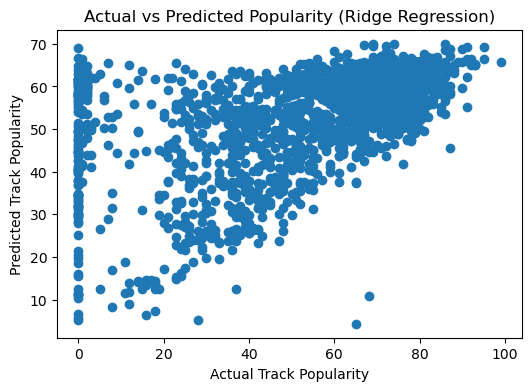

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, ridge_pred)
plt.xlabel("Actual Track Popularity")
plt.ylabel("Predicted Track Popularity")
plt.title("Actual vs Predicted Popularity (Ridge Regression)")
plt.show()
